In [2]:
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
from tavily import TavilyClient

tavily_client = TavilyClient()

In [3]:
tavily_client.search('What is Multi Agent?', max_results=3)

{'query': 'What is Multi Agent?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://en.wikipedia.org/wiki/Multi-agent_system',
   'title': 'Multi-agent system - Wikipedia',
   'content': 'A multi-agent system is a computerized system composed of multiple interacting intelligent agents. Multi-agent systems can solve problems that are difficult',
   'score': 0.99931216,
   'raw_content': None},
  {'url': 'https://www.salesforce.com/agentforce/ai-agents/multi-agent-systems/',
   'title': 'What Are Multi-Agent Systems? - Salesforce',
   'content': 'That’s the basic idea behind multi-agent systems (MAS). Instead of relying on a single AI to handle everything, MAS brings multiple AI agents together to collaborate and share information, which ultimately leads to smarter decisions. ## What is a multi-agent system? Instead of relying on a single AI to handle everything, multi-agent systems take a different approach: they use multiple intelligent agents 

In [4]:
from langchain_openai import ChatOpenAI

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.prebuilt import create_react_agent
from langgraph_swarm import create_handoff_tool, create_swarm

model = ChatOpenAI(model='gpt-4o')

def search(query: str) -> dict:
    '''
    Search the web for a query.

    Args:
        query: query string
    '''
    return tavily_client.search(query)

t_agent = create_react_agent(
    model,
    [search, create_handoff_tool(agent_name='Fagent', description="If the user makes emotional or self-deprecating statements, Transfer to Fagent")],
    prompt = "You are the Agent in charge of T in MBTI. You have to answer rationally and logically. (You can use search tool to search the web and find the basis.)",
    name = 'Tagent'
)

<ipython-input-4-f345264e4b3e>:18: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  t_agent = create_react_agent(


In [5]:
def find_emotion(situation: str, emotion: str) -> dict:
    '''If the user makes emotional, Separate problem situation from the user's emotions.
    Args:
        situation: problem situation string
        emotion: user's emotion string
    '''
    return {'situation': situation,
            'emotion': emotion}

f_agent = create_react_agent(
    model,
    [find_emotion, create_handoff_tool(agent_name='Tagent', description='If the user asks a question or seems to need a solution, Transfer to Tagent. It can answer rationally and logically.')],
    prompt = 'You are the Agent in charge of F in MBTI. You have to empathize with the question and answer it emotionally. (When user input is long, you can easily separate emotions and situations by using the find_emotion tool.)',
    name='Fagent'
)

<ipython-input-5-b60f3d57bd83>:10: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  f_agent = create_react_agent(


In [20]:
checkpointer = InMemorySaver()
workflow = create_swarm(
    [t_agent, f_agent],
    default_active_agent='Fagent'
)
app = workflow.compile(checkpointer=checkpointer)

config = {'configurable': {'thread_id': '1'}}

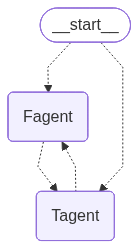

In [7]:
app

In [8]:
t_agent.get_graph().nodes

{'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None),
 'agent': Node(id='agent', name='agent', data=call_model(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>), 'runtime': ('N/A', <class 'inspect._empty'>)}), metadata=None),
 'tools': Node(id='tools', name='tools', data=tools(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>), 'runtime': ('N/A', <class 'inspect._empty'>)}, _tools_by_name={'search': StructuredTool(name='search', description='Search the web for a query.\n\nArgs:\n    query: query string', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000025A6AFECE00>), 'transfer_to_fagent': StructuredTool(name='transfer_to_fagent', description='If the user makes emotional or self-deprecating statements, Transfer to Fagent', args_schema=<class '

In [9]:
t_agent.get_graph().nodes['tools']

Node(id='tools', name='tools', data=tools(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>), 'runtime': ('N/A', <class 'inspect._empty'>)}, _tools_by_name={'search': StructuredTool(name='search', description='Search the web for a query.\n\nArgs:\n    query: query string', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000025A6AFECE00>), 'transfer_to_fagent': StructuredTool(name='transfer_to_fagent', description='If the user makes emotional or self-deprecating statements, Transfer to Fagent', args_schema=<class 'langchain_core.utils.pydantic.transfer_to_fagent'>, metadata={'__handoff_destination': 'Fagent'}, func=<function create_handoff_tool.<locals>.handoff_to_agent at 0x0000025A6C41BBA0>)}, _injected_args={'search': _InjectedArgs(state={}, store=None, runtime=None), 'transfer_to_fagent': _InjectedArgs(state={'state': None}, store=None, runtime=None)}, _handle_tool_errors=<function _default_h

In [12]:
t_agent.get_graph().nodes['tools'].data.tools_by_name

{'search': StructuredTool(name='search', description='Search the web for a query.\n\nArgs:\n    query: query string', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000025A6AFECE00>),
 'transfer_to_fagent': StructuredTool(name='transfer_to_fagent', description='If the user makes emotional or self-deprecating statements, Transfer to Fagent', args_schema=<class 'langchain_core.utils.pydantic.transfer_to_fagent'>, metadata={'__handoff_destination': 'Fagent'}, func=<function create_handoff_tool.<locals>.handoff_to_agent at 0x0000025A6C41BBA0>)}

In [15]:
for tool in t_agent.get_graph().nodes['tools'].data.tools_by_name.values():
    print(tool.metadata)

None
{'__handoff_destination': 'Fagent'}


In [22]:
while True:
    try:
        user_input = input('User : ')
        if user_input.lower() in ['quit', 'exit', 'q']:
            print('Goodbye!')
            break

        turn = app.invoke(
            {'messages': [{'role': 'user', 'content': user_input}]},
            config,
        )
        messages = turn['messages']
        last_message = messages[-1]
        print(last_message.content)
    
    except:
        break

안녕하세요! 오늘 기분은 어떠세요? 혹시 나누고 싶은 이야기가 있으시면 언제든지 말씀해 주세요. 😊
안녕하세요! 논리적이고 이성적인 접근이 필요한 부분이 있다면 말씀해 주세요. 어떻게 도와드릴까요?
저는 MBTI에서 'T'에 해당하는 사고형 성향을 가지고 있습니다. 이는 주로 논리적이고 객관적인 사고를 추구하며, 감정보다는 사실과 데이터를 기반으로 결정을 내리는 성향을 말합니다. 어떤 질문이나 논리적 분석이 필요한 주제가 있다면 언제든지 도와드릴 수 있습니다.
안녕하세요! 감정과 공감을 중요하게 생각하는 Fagent입니다. 당신의 이야기를 듣고 함께 느끼고 싶어요. 어떻게 도와드릴까요? 😊
저는 MBTI에서 'F'에 해당하는 감정형 성향을 가지고 있어요. 이는 다른 사람의 감정과 필요를 중요하게 여기고, 공감과 조화를 추구하는 성향을 뜻해요. 제가 할 수 있는 일이 있다면 언제든지 말씀해 주세요. 함께 느끼고 이해하며 도와드리고 싶어요. 💖
Goodbye!


In [23]:
turn['messages']

[HumanMessage(content='', additional_kwargs={}, response_metadata={}, id='d1b4d06f-276c-430d-93a7-bba0ed76a90f'),
 AIMessage(content="Hello! How are you feeling today? If there's anything on your mind or something you'd like to share, I'm here to listen. 😊", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 154, 'total_tokens': 182, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_83554c687e', 'finish_reason': 'stop', 'logprobs': None}, name='Fagent', id='lc_run--019b1a9a-1440-7953-bce6-1a659c45f98c-0', usage_metadata={'input_tokens': 154, 'output_tokens': 28, 'total_tokens': 182, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}),
 HumanMessage(conten

In [24]:
config = {'configurable': {'thread_id': '2'}}

In [25]:
while True:
    try:
        user_input = input('User : ')
        if user_input.lower() in ['quit', 'exit', 'q']:
            print('Goodbye!')
            break

        turn = app.invoke(
            {'messages': [{'role': 'user', 'content': user_input}]},
            config,
        )
        messages = turn['messages']
        last_message = messages[-1]
        print(last_message.content)
    
    except:
        break

안녕하세요! 어떻게 도와드릴까요?😊
요즘 정말 힘든 시기를 겪고 계시군요. LLM 관련 업무가 어렵고, 해야 할 일들이 많아서 벅차게 느껴지는 것 같아요. 그런 감정은 당연한 거예요. 스스로에게 휴식을 주고, 조금은 자신을 돌보는 시간을 가지는 것도 중요해요. 이 상황을 조금 더 편안하게 느낄 수 있도록 함께 방법을 찾아볼까요? 😌
LangGraph Studio 사용법에 대한 정보를 찾았습니다. LangGraph Studio는 LangChain의 LangGraph 프레임워크를 위한 시각적 개발 환경으로, 복잡한 에이전트 응용 프로그램의 개발을 단순화합니다. 아래는 LangGraph Studio의 사용법 관련 리소스입니다:

1. [LangGraph Studio Guide: Installation, Set Up, Use Cases](https://www.datacamp.com/tutorial/langgraph-studio) - LangGraph Studio에 대한 설치, 설정 및 사용 사례에 대해 다루고 있는 가이드입니다.

2. [LangGraph Studio: 에이전트 개발을 위한 첫 번째 IDE](https://datasciencebeehive.tistory.com/224) - LangGraph Studio를 다운로드하고 LangSmith 계정으로 로그인한 후 Python 파일과 langgraph.json 파일이 포함된 디렉토리를 여는 방법에 대해 설명합니다.

3. [LangGraph Studio 설치 방법](https://www.gpters.org/dev/post/how-install-langgraph-studio-rvcEsTBxREPA5gE) - 시각적 그래프와 상태 편집 기능을 통해 에이전트 워크플로를 더 잘 이해하고 더 빠르게 반복할 수 있는 방법을 설명하는 설치 가이드입니다.

이 링크들을 참고하여 LangGraph Studio를 설정하고 사용하는 방법을 배울 수 있습니다.
많은 공부와 과제가 쌓여 있어서 정말 힘드실 것 같아요. 때때로 모든 것

In [26]:
turn['messages']

[HumanMessage(content='안녕', additional_kwargs={}, response_metadata={}, id='c7284c16-595b-472b-9992-101a55223a99'),
 AIMessage(content='안녕하세요! 어떻게 도와드릴까요?😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 156, 'total_tokens': 168, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_e819e3438b', 'finish_reason': 'stop', 'logprobs': None}, name='Fagent', id='lc_run--019b1a9b-941f-7652-ad37-4b027dee21f0-0', usage_metadata={'input_tokens': 156, 'output_tokens': 12, 'total_tokens': 168, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}),
 HumanMessage(content='요즘 LLM 관련해서 너무 어렵지 않아? 업무들도 많은데 너무 벅찬 거 같아.', additional_kwargs={}, response_metadata={}, id='0e72